In [1]:
import numpy as np
import matplotlib.pyplot as plt


from tqdm.notebook import trange, tqdm


from matplotlib import rc
 

rc('font',**{'family':'sans-serif','sans-serif':['Fira Sans'],'size':14,'style':'normal'})
rc('text', usetex=False)


BLUE = 'xkcd:pastel blue'
RED = 'xkcd:pastel red'
GREEN = 'xkcd:pastel green'
YELLOW ='xkcd:pastel pink'
PURPLE = 'xkcd:pastel purple'
DBLUE = 'xkcd:light navy blue'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[BLUE, RED, GREEN, YELLOW,PURPLE,DBLUE])


In [2]:
# def ramsey_H(f, Omega, T):
#     lowpass = (Omega**2 / (Omega**2 - (2*np.pi*f)**2))**2
#     sinc_term = np.sin(np.pi*f*T) / (np.pi*f*T)
#     edge_term = 2/(Omega*T) * np.cos(np.pi**2*f/Omega + np.pi*f*T)

#     return T**2 * (sinc_term + edge_term)**2 * lowpass


def ramsey_H(f, Omega, T):
    numerator = (
        np.sin(np.pi*f*T)
        + (2*f/(np.pi*Omega))*np.cos(np.pi*f*(np.pi + T*Omega)/Omega)
    )
    return (numerator / (np.pi*f))**2 * (Omega**2 / (Omega**2 - (2*np.pi*f)**2))**2



def ramsey_H_no_edge(f, Omega, T):
    numerator = (
        np.sin(np.pi*f*T))
    return (numerator / (np.pi*f))**2 * (Omega**2 / (Omega**2 - (2*np.pi*f)**2))**2

def noise_psd(f,B,delta):
    return (2*np.pi*f)**2/((2*np.pi*f)**2+B**2)*2*delta

In [3]:
f = np.linspace(5,1000,10000)
f0 = 100
Omega = 2*np.pi*f0
T = 100
B = 10000

In [4]:
Omega2 = -2/T*np.arctan(np.pi/2)+2e2*np.pi

In [5]:
Omega2/(2*np.pi)

np.float64(99.99680453536615)

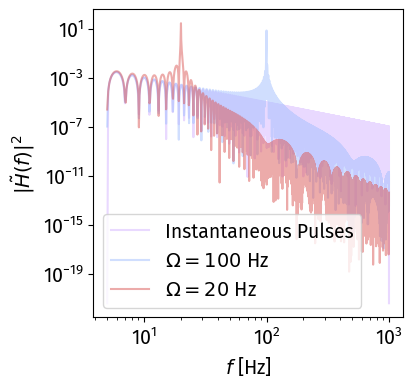

In [26]:
plt.figure(figsize = (4,4))
plt.plot(f,ramsey_H(f,1e10,T),alpha = 0.4,label = 'Instantaneous Pulses', color = PURPLE)
plt.plot(f,ramsey_H(f,100*np.pi*2,T),alpha = 0.5,label = '$\Omega = 100$ Hz')
# plt.plot(f,ramsey_H_no_edge(f,Omega,T),'--',alpha = 0.6,label = '$\Omega = 100$ Hz (no edge terms)')
plt.plot(f,ramsey_H(f,20*np.pi*2,T),alpha = 0.5,label = '$\Omega = 20$ Hz', color = RED)



plt.ylabel(r'$|\tilde{H}(f)|^2$')
plt.xlabel('$f$ [Hz]')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc = 'lower left')

# plt.ylim([1e-15,10000])

plt.savefig('plots/rabi_freq_laser_noise.pdf',bbox_inches ='tight') 

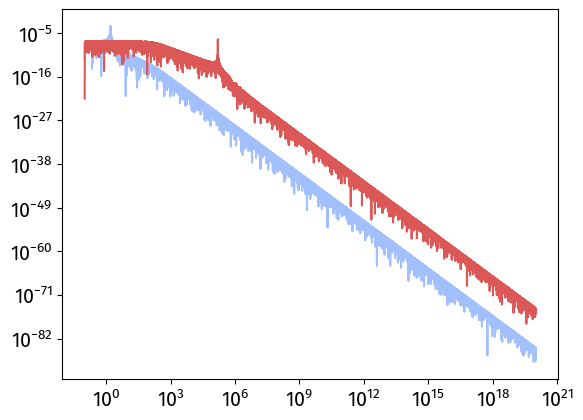

In [14]:
f = np.logspace(-1,20,10000)
Omega = 10
plt.plot(f,ramsey_H(f, Omega, T)*noise_psd(f,1000,10e-3))
plt.plot(f,ramsey_H(f, Omega*1e5, T)*noise_psd(f,1000,10e-3))
plt.xscale('log')
plt.yscale('log')

In [15]:
omega = np.logspace(-0,np.pi**2,100000)
omega2 = np.logspace(-0,np.pi**2+0.01,100000)
total_noise =[]
total_noise2 =[]
for Omega in tqdm(omega):
    total_noise.append(np.trapezoid(ramsey_H(f, Omega, T)*noise_psd(f,10000,10e-3),f))
    
for Omega in tqdm(omega2):
    total_noise2.append(np.trapezoid(ramsey_H(f, Omega, T)*noise_psd(f,10000,10e-3),f))

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

Text(0, 0.5, '$\\sigma_{\\Omega}/\\sigma_{\\mathrm{inst.}}$')

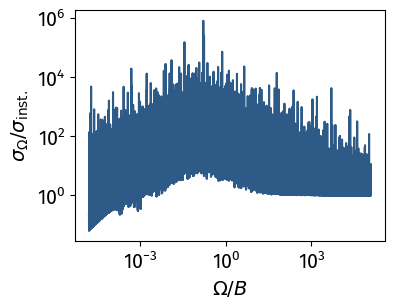

In [25]:
plt.figure(figsize = (4,3))
plt.plot(omega/(2*np.pi*10000),np.sqrt(total_noise/np.trapezoid(ramsey_H(f, 1e12, T)*noise_psd(f,10000,10e-3),f)),color = DBLUE)

plt.plot(omega2/(2*np.pi*10000),np.sqrt(total_noise2/np.trapezoid(ramsey_H(f, 1e12, T)*noise_psd(f,10000,10e-3),f)),color = DBLUE)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Omega/B$')
plt.ylabel('$\sigma_{\Omega}/\sigma_{\mathrm{inst.}}$')
# plt.savefig('plots/finite_rabi_noise.pdf',bbox_inches = 'tight')

np.float64(0.026246691902568828)

TypeError: ramsey_H() missing 1 required positional argument: 'T'

  0%|          | 0/100 [00:00<?, ?it/s]

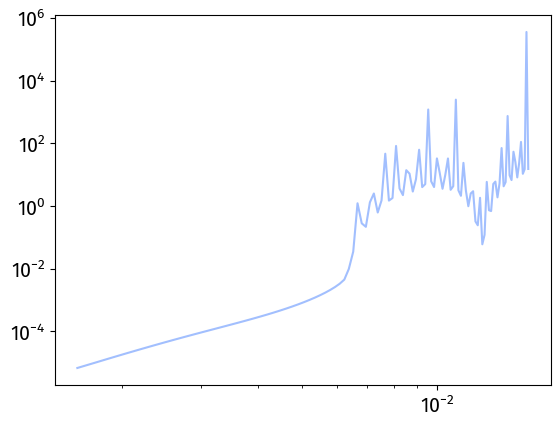

In [72]:
plt.plot(rabis/B,noise)
plt.yscale('log')
plt.xscale('log')

In [2]:
def Hf_max(omega,T):
    num = np.pi*np.cos(omega*T/2)+2*np.sin(omega*T/2)
    den = 2*omega
    return (num/den)**2

In [7]:
T = 100
omega = np.logspace(0,1,10000)

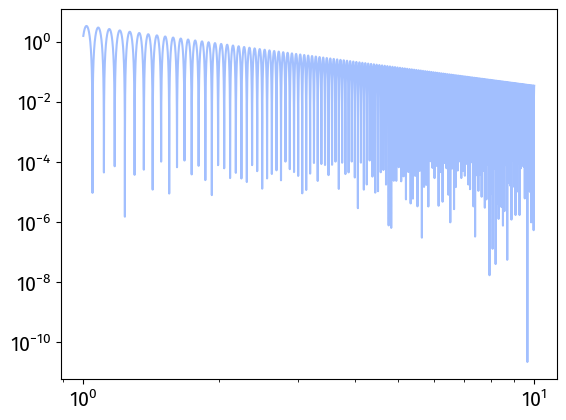

In [9]:
plt.plot(omega,Hf_max(omega,T))
plt.xscale('log')
plt.yscale('log')